In [1]:
import xtrack as xt
import xpart as xp
import xdeps as xd
import xobjects as xo

from cpymad.madx import Madx
import numpy as np
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

import spintools as spt
import kicktools as kt
import tracktools as tk
from chirp_kicker import VerticalChirpKicker

/home/eris/miniconda3/envs/xsuite-env/lib/python3.11/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
lattice_file = 'LCC_105-0-0_z_line_00_optics_corrected_seed49_incl_radiation_6Dmethod.json'
line = xt.Line.from_json(lattice_file)

spin_tune_ref = 0.00115965218091*45.6e3/0.5109989461
nusEnergy = spt.EforSpinTune(spin_tune_ref)
spt.setupLine4Pol(line, nusEnergy)

print(f'Spin tune      = {spin_tune_ref:.4f}')
print(f'Energy         = {line.particle_ref.p0c[0]/1E9:.4f} GeV')
print(f'Energy (check) = {spt.EforSpinTune(spin_tune_ref):.4f} GeV')

Loading line from dict:   0%|          | 0/21288 [00:00<?, ?it/s]

Done loading line from dict.           
Spin tune      = 103.4839
Energy         = 45.6000 GeV
Energy (check) = 45.6000 GeV


In [3]:
tt = line.get_table()
cav_name = tt.rows[tt.element_type == 'Cavity'].name[0] # Get the first cavity
print(f"Checking Cavity: {cav_name}")
print(f"Voltage: {line[cav_name].voltage}")
print(f"Frequency:     {line[cav_name].frequency}")
print(f"Lag:     {line[cav_name].lag}")

Checking Cavity: rf400
Voltage: 150000000.0
Frequency:     400848491.0
Lag:     144.0


In [4]:
line.configure_radiation('mean')
# apply tapering
#line.compensate_radiation_energy_loss(solve_tapering=True)

tw = line.twiss(spin=True,eneloss_and_damping=True, polarization=True) 

In [5]:
# 1. Define exactly the 1D parameters you want to save
# You can add 'px', 'py', 'dx', 'dy', 'alfx', 'alfy', etc.
desired_params = ['name', 's', 'x', 'y', 'betx', 'bety', 'spin_x', 'spin_y', 'spin_z']

# 2. Extract only those columns directly from the TwissTable
tw_dict = {param: tw[param] for param in desired_params}

# 3. Create the DataFrame safely
df = pd.DataFrame(tw_dict)

# --- Create the MAD-X style table (EXIT values) ---
# Slice from row 1 to the end for the numerical values
df_exit = df.iloc[1:].copy()

# Assign the element names from the previous rows
df_exit['name'] = df['name'].iloc[:-1].values

# Save to CSV
df_exit.to_csv('twiss.csv', index=False)

In [6]:
rms_y_all = np.sqrt(np.mean(tw.y**2))
print(f"RMS Y (all elements): {rms_y_all:.6e} m")

RMS Y (all elements): 2.518847e-05 m


In [7]:
spt.printRaditionPol(tw)
frac_spin_tune=tw.spin_tune_fractional

Qx / Qy   = 194.1667 / 170.2002
Qx' / Qy' = 0.3907 / 0.1616
Alpha_c   = 2.8620e-05
Revolution period = 302.359 [microsec]
P0c       = 45.60000 [GeV]
Ref. Spin tune  = 103.483852
Frac. Spin tune = 0.481090
Equ. pol  = 68.821 %
Eloss/turn      = 34.752 [MeV]
Qs              = 0.04215
Sigma_z         = 0.0037 [m]
Sigma_E/E       = 0.3708 [permill]
Spin mod index  = 0.9102
Emitx / Emity   = 0.7687 / 0.0000 [nm]
Damping part No = 1.0008 / 1.0000 / 1.9992


In [8]:
sigma_e_e = np.sqrt(tw.eq_gemitt_zeta / tw.bets0)
sigma_z = np.sqrt(tw.eq_gemitt_zeta * tw.bets0)
spin_mod_index = spin_tune_ref * sigma_e_e / tw.qs

# 2. Write everything to the file
with open('twiss2.txt', 'w') as f:
    f.write(f"RMS Y (all elements): {np.sqrt(np.mean(tw.y**2)):.6e} m\n")
    f.write("-" * 40 + "\n")
    f.write(f"Qx / Qy   = {tw.qx:.4f} / {tw.qy:.4f}\n")
    f.write(f"Qx' / Qy' = {tw.dqx:.4f} / {tw.dqy:.4f}\n")
    f.write(f"Alpha_c   = {tw.momentum_compaction_factor:.4e}\n")
    f.write(f"Revolution period = {tw.t_rev0*1e6:.3f} [microsec]\n")
    f.write(f"P0c       = {tw.p0c*1E-9:.5f} [GeV]\n")
    f.write(f"Ref. Spin tune  = {spin_tune_ref:.6f}\n")
    f.write(f"Frac. Spin tune = {tw.spin_tune_fractional:.6f}\n")
    f.write(f"Equ. pol  = {tw.spin_polarization_eq*100:.3f} %\n")
    f.write(f"Eloss/turn      = {tw.energy_loss/1e6:.3f} [MeV]\n")    
    f.write(f"Qs              = {tw.qs:.5f}\n")
    f.write(f"Sigma_z         = {sigma_z:.4f} [m]\n")
    f.write(f"Sigma_E/E       = {1000*sigma_e_e:.4f} [permill]\n")
    f.write(f"Spin mod index  = {spin_mod_index:.4f}\n")
    f.write(f"Emitx / Emity   = {tw.rad_int_eq_gemitt_x*1e9:.4f} / {tw.rad_int_eq_gemitt_y*1e9:.4f} [nm]\n")
    f.write(f"Damping part No = {tw.partition_numbers[0]:.4f} / {tw.partition_numbers[1]:.4f} / {tw.partition_numbers[2]:.4f}\n")

In [9]:
element_name = 'qd1a.0'  #'qd3.1'   #'qd1a.0'

# Find the index of the element in the Twiss table
# np.where returns an array of matching indices, we take the first one [0][0]
idx = np.where(tw.name == element_name)[0][0]

# The values at the END of this element correspond to the START of the next one
betx_end = tw.betx[idx + 1]
bety_end = tw.bety[idx + 1]

print(f"Beta X at end of {element_name}: {betx_end:.4f} m")
print(f"Beta Y at end of {element_name}: {bety_end:.4f} m")

Beta X at end of qd1a.0: 47.6407 m
Beta Y at end of qd1a.0: 126.8959 m


In [10]:
ac_kicker = VerticalChirpKicker(
        length=0.1, 
        k0sl=0, # peak value
        q_start=0,
        q_span=0,
        num_turns=10000, # Duration of the scan
)

line.insert('spin_kicker', obj=ac_kicker, at='qd1a.0@end')


Slicing line:   0%|          | 0/21280 [00:00<?, ?it/s]

In [11]:
line.configure_radiation('mean')
#line.configure_radiation(model=None)

num_particle=100

np.random.seed(0)
particles = xp.generate_matched_gaussian_bunch(
        line=line,
        nemitt_x=tw.eq_nemitt_x,
        nemitt_y=tw.eq_nemitt_y,
        sigma_z=np.sqrt(tw.eq_gemitt_zeta * tw.bets0),
        num_particles=num_particle)

Compiling ContextCpu kernels...


In file included from f623aee5b1f7427f97717c932a0f5e65.c:25623:
/home/eris/miniconda3/envs/xsuite-env/lib/python3.11/site-packages/xtrack/beam_elements/elements_src/drift_slice_rbend.h: In function ‘DriftSliceRBend_track_local_particle’:
/home/eris/miniconda3/envs/xsuite-env/lib/python3.11/site-packages/xtrack/beam_elements/elements_src/drift_slice_rbend.h:25:20: warning: unused variable ‘full_length’ [-Wunused-variable]
   25 |             double full_length;
      |                    ^~~~~~~~~~~


Done compiling ContextCpu kernels.


In [12]:
# Add stable phase to particle coordinates
particles.zeta += tw.zeta[0]
particles.delta += tw.delta[0]

In [13]:
# 1. 提取并归一化 n0, u, v 坐标系 (与之前相同)
n0 = np.array([tw.spin_x[0], tw.spin_y[0], tw.spin_z[0]])
n0 = n0 / np.linalg.norm(n0) 

aux_vec = np.array([1.0, 0.0, 0.0]) if abs(n0[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
u = np.cross(n0, aux_vec)
u = u / np.linalg.norm(u)
v = np.cross(n0, u)

# 2. 根据目标极化率计算正态分布的标准差 sigma
P_eq = tw.spin_polarization_eq

# 注意：P_eq 必须在 (0, 1] 之间，这对电子/正电子环(如Sokolov-Ternov极化)天然成立
sigma_theta = np.sqrt(-2.0 * np.log(P_eq))

# 3. 生成服从正态分布的 theta (中心=0, 标准差=sigma_theta)
# 这里的 theta 是弧度制。正态分布的尾部即使超过了 +/- pi，
# 后续的 cos() 和 sin() 函数也会自动完美处理这种周期性"缠绕"(wrapping)。
# 生成原始的正态分布
theta_raw = np.random.normal(loc=0.0, scale=sigma_theta, size=num_particle)

# 强制映射回 [-pi, pi]
theta = (theta_raw + np.pi) % (2 * np.pi) - np.pi


# 4. 生成在 u-v 平面上投影的 2pi 随机方位角 phi
phi = np.random.uniform(0, 2 * np.pi, num_particle)

# 5. 将分布赋予 Xsuite 粒子对象
particles.spin_x = np.cos(theta) * n0[0] + np.sin(theta) * (np.cos(phi) * u[0] + np.sin(phi) * v[0])
particles.spin_y = np.cos(theta) * n0[1] + np.sin(theta) * (np.cos(phi) * u[1] + np.sin(phi) * v[1])
particles.spin_z = np.cos(theta) * n0[2] + np.sin(theta) * (np.cos(phi) * u[2] + np.sin(phi) * v[2])

In [14]:
initial_pol_x = np.mean(particles.spin_x)
initial_pol_y = np.mean(particles.spin_y)
initial_pol_z = np.mean(particles.spin_z)

print(f"Initial Macroscopic Polarization (Px, Py, Pz): ({initial_pol_x:.6f}, {initial_pol_y:.6f}, {initial_pol_z:.6f})")

Initial Macroscopic Polarization (Px, Py, Pz): (-0.050081, 0.680036, 0.044365)


In [15]:
# 1. Calculate the macroscopic average vector in global coordinates
P_global = np.array([
    np.mean(particles.spin_x),
    np.mean(particles.spin_y),
    np.mean(particles.spin_z)
])

# 2. Project this average vector onto your local coordinate axes
P_n0 = np.dot(P_global, n0)
P_u = np.dot(P_global, u)
P_v = np.dot(P_global, v)

# 3. Output the results
print("--- Initial Macroscopic Polarization Projections ---")
print(f"Average along n0 (P_n0): {P_n0:.6f}  (Expected: ~ {P_eq:.6f})")
print(f"Average along u  (P_u) : {P_u:.6e}  (Expected: ~ 0.0)")
print(f"Average along v  (P_v) : {P_v:.6e}  (Expected: ~ 0.0)")

--- Initial Macroscopic Polarization Projections ---
Average along n0 (P_n0): 0.680375  (Expected: ~ 0.688207)
Average along u  (P_u) : -4.035127e-02  (Expected: ~ 0.0)
Average along v  (P_v) : 4.885392e-02  (Expected: ~ 0.0)


In [16]:
line.configure_spin('auto')
line.configure_radiation('quantum')

num_turn=20000

ac_kicker.k0sl=2e-6
ac_kicker.q_span=0.006
ac_kicker.q_start=frac_spin_tune-0.6*ac_kicker.q_span   
ac_kicker.num_turns=num_turn

print('Scan from '+str(ac_kicker.q_start)+' to '+str(ac_kicker.q_start+ac_kicker.q_span))

line.discard_tracker()
print('Going multi-threaded....')
line.build_tracker(_context=xo.ContextCpu(omp_num_threads=30))

line.track(particles, num_turns=num_turn, turn_by_turn_monitor=True, with_progress=1000)

Scan from 0.4774904959875254 to 0.4834904959875254
Going multi-threaded....
Compiling ContextCpu kernels...


In file included from 43c03aced4b0473d8262fbce439b3a67.c:25624:
/home/eris/miniconda3/envs/xsuite-env/lib/python3.11/site-packages/xtrack/beam_elements/elements_src/drift_slice_rbend.h: In function ‘DriftSliceRBend_track_local_particle’:
/home/eris/miniconda3/envs/xsuite-env/lib/python3.11/site-packages/xtrack/beam_elements/elements_src/drift_slice_rbend.h:25:20: warning: unused variable ‘full_length’ [-Wunused-variable]
   25 |             double full_length;
      |                    ^~~~~~~~~~~


Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/20000 [00:00<?, ?it/s]

In [17]:
mon = line.record_last_track

In [18]:
mask_alive = mon.state > 0

print(mon.state)

pol_x = mon.spin_x.sum(axis=0)/mask_alive.sum(axis=0)
pol_y = mon.spin_y.sum(axis=0)/mask_alive.sum(axis=0)
pol_z = mon.spin_z.sum(axis=0)/mask_alive.sum(axis=0)

pol_xz = np.sqrt(pol_x**2 +pol_z**2)
pol = np.sqrt(pol_x**2 + pol_y**2 + pol_z**2)

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


In [19]:
turns = np.arange(num_turn)

pol_data = {
    'turn': turns,
    'pol_x': pol_x,
    'pol_y': pol_y,
    'pol_z': pol_z
}

df_pol = pd.DataFrame(pol_data)
df_pol.to_csv('P_rdp_tbt2.csv', index=False)

In [22]:
nu_ac=[ac_kicker.q_start+i*ac_kicker.q_span/num_turn for i in turns]

def logistic(nu_ac, Pfinal, Pinit, nu_res, w):
    return Pfinal + (Pinit - Pfinal) / (1 + np.exp((nu_ac - nu_res)/w))

# Initial guesses for the fit parameters
p0 = [0.65, 0.68, 0.481, 1]  # P_final, P_init, turn_res, width

# Fit the curve
popt, pcov = curve_fit(logistic, nu_ac, pol_y, p0=p0)
P_final, P_init, nu_res, w = popt
nu_res_err = np.sqrt(pcov[2, 2])

# Compute R^2
residuals = pol_y - logistic(nu_ac, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((pol_y - np.mean(pol_y))**2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

nu_ac_fit = np.linspace(min(nu_ac), max(nu_ac), 2000)
pol_y_fit = logistic(nu_ac_fit, *popt)

0.9567145752989099


/tmp/ipykernel_1242/560712537.py:4: RuntimeWarning: overflow encountered in exp
  return Pfinal + (Pinit - Pfinal) / (1 + np.exp((nu_ac - nu_res)/w))


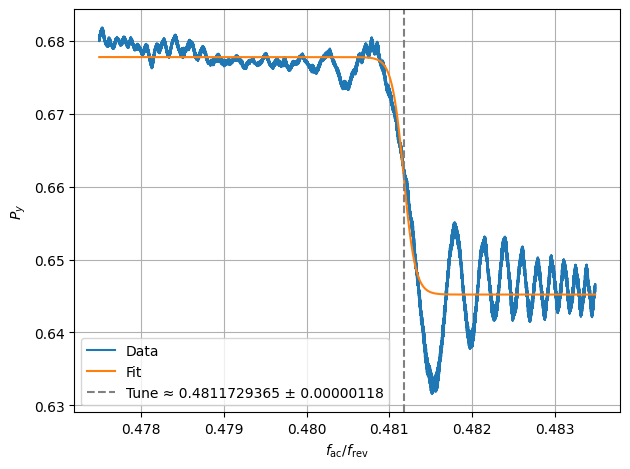

In [23]:
plt.clf()
plt.plot(nu_ac, pol_y, label='Data')
plt.plot(nu_ac_fit, pol_y_fit, label='Fit')  
plt.axvline(nu_res, color='gray', linestyle='--', label=f'Tune ≈ {nu_res:.10f} ± {nu_res_err:.8f}')
plt.xlabel(r'$f_{\mathrm{ac}}/f_{\mathrm{rev}}$')
plt.ylabel(r'$P_y$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_rdp2.png", dpi=300) 
plt.show()